# Multi-Layer Perceptron (MLP) - Klasifikasi Kesejahteraan Pekerja Indonesia

Notebook ini membangun model MLP untuk mengklasifikasikan tingkat kesejahteraan pekerja Indonesia berdasarkan data upah, pengeluaran, UMP, dan garis kemiskinan per provinsi per tahun.

**Dataset:** [Kesejahteraan Pekerja Indonesia (Kaggle)](https://www.kaggle.com/datasets/rezkyyayang/pekerja-sejahtera)

## 1. Import Library

In [166]:
import pandas as pd                        # pandas: library utama untuk manipulasi data tabular (DataFrame & Series)
import numpy as np                         # numpy: library komputasi numerik, array multidimensi, dan operasi matematika
import matplotlib.pyplot as plt            # matplotlib.pyplot: library visualisasi dasar untuk membuat plot & grafik
import seaborn as sns                      # seaborn: library visualisasi statistik berbasis matplotlib, tampilan lebih rapi

from sklearn.model_selection import train_test_split   # fungsi untuk membagi dataset menjadi data train & test
from sklearn.preprocessing import StandardScaler       # StandardScaler: normalisasi fitur agar mean=0 dan std=1
from sklearn.preprocessing import LabelEncoder         # LabelEncoder: mengubah label kategori (string) menjadi angka integer
from sklearn.neural_network import MLPClassifier       # MLPClassifier: model Multi-Layer Perceptron dari scikit-learn
from sklearn.metrics import classification_report      # classification_report: laporan evaluasi per kelas (precision, recall, f1)
from sklearn.metrics import confusion_matrix           # confusion_matrix: matriks prediksi benar/salah per kelas
from sklearn.metrics import accuracy_score             # accuracy_score: menghitung persentase prediksi yang benar
import joblib                              # joblib: library untuk menyimpan dan memuat objek Python (model, scaler, dll)

plt.rcParams['figure.figsize'] = (8, 5)   # set ukuran default semua plot menjadi 8x5 inci
sns.set_style('whitegrid')                # set tema seaborn dengan background putih + grid abu-abu
print('Library berhasil di-import!')      # konfirmasi semua library berhasil dimuat tanpa error

Library berhasil di-import!


## 2. Load Dataset

Memuat 4 file CSV dari Kaggle:
- `upah_df.csv` — data upah pekerja per provinsi & tahun
- `peng_df.csv` — data pengeluaran per kapita
- `ump_df.csv` — data Upah Minimum Provinsi (UMP)
- `gk_df.csv` — data Garis Kemiskinan

In [167]:
upah = pd.read_csv('upah_df.csv')  # membaca file CSV upah → disimpan sebagai DataFrame 'upah' (280 baris x 3 kolom)
peng = pd.read_csv('peng_df.csv')  # membaca file CSV pengeluaran → DataFrame 'peng' (4620 baris x 5 kolom)
ump  = pd.read_csv('ump_df.csv')   # membaca file CSV UMP (Upah Minimum Provinsi) → DataFrame 'ump' (735 baris x 3 kolom)
gk   = pd.read_csv('gk_df.csv')   # membaca file CSV garis kemiskinan → DataFrame 'gk' (5460 baris x 6 kolom)

print('Shape upah:', upah.shape)   # tampilkan dimensi DataFrame upah: (jumlah baris, jumlah kolom)
print('Shape peng:', peng.shape)   # tampilkan dimensi DataFrame peng
print('Shape ump :', ump.shape)    # tampilkan dimensi DataFrame ump
print('Shape gk  :', gk.shape)     # tampilkan dimensi DataFrame gk

Shape upah: (280, 3)
Shape peng: (4620, 5)
Shape ump : (735, 3)
Shape gk  : (5460, 6)


## 3. Exploratory Data Analysis (EDA)

Sebelum preprocessing, kita pahami terlebih dahulu struktur dan distribusi data.

### 3.1 Cek Data Awal

In [168]:
print('=== Upah ===')             # header pemisah untuk output agar mudah dibaca
print(upah.head(5))               # tampilkan 5 baris pertama DataFrame upah untuk melihat struktur data
print(upah.dtypes)                # tampilkan tipe data setiap kolom (object=string, int64=integer, float64=desimal)

print('\n=== Pengeluaran ===')     # \n = newline, memberi jarak antar bagian output
print(peng.head(3))               # tampilkan 3 baris pertama DataFrame peng

print('\n=== UMP ===')
print(ump.head(3))                # tampilkan 3 baris pertama DataFrame ump

print('\n=== Garis Kemiskinan ===')
print(gk.head(3))                 # tampilkan 3 baris pertama DataFrame gk

=== Upah ===
  provinsi  tahun   upah
0     ACEH   2015  11226
1     ACEH   2016  13627
2     ACEH   2017  14809
3     ACEH   2018  13814
4     ACEH   2019  15065
provinsi    object
tahun        int64
upah         int64
dtype: object

=== Pengeluaran ===
  provinsi     daerah    jenis  tahun      peng
0     ACEH  PERDESAAN  MAKANAN   2007  195176.0
1     ACEH  PERDESAAN  MAKANAN   2008  218781.0
2     ACEH  PERDESAAN  MAKANAN   2009  247427.0

=== UMP ===
  provinsi  tahun       ump
0     ACEH   2002  330000.0
1     ACEH   2003  425000.0
2     ACEH   2004  550000.0

=== Garis Kemiskinan ===
  provinsi    jenis     daerah  tahun    periode        gk
0     ACEH  MAKANAN  PERKOTAAN   2015      MARET  293697.0
1     ACEH  MAKANAN  PERKOTAAN   2015  SEPTEMBER  302128.0
2     ACEH  MAKANAN  PERKOTAAN   2016      MARET  306243.0


### 3.2 Statistik Deskriptif

In [169]:
print('Statistik Upah:')
print(upah['upah'].describe())    # hitung statistik ringkas kolom upah: count, mean, std, min, 25%, 50%, 75%, max

print('\nStatistik Pengeluaran:')
print(peng['peng'].describe())    # hitung statistik ringkas kolom peng untuk memahami sebaran nilai pengeluaran

Statistik Upah:
count      280.000000
mean     16621.010714
std       4371.803056
min       8525.000000
25%      13468.750000
50%      15845.000000
75%      18634.750000
max      32685.000000
Name: upah, dtype: float64

Statistik Pengeluaran:
count    4.512000e+03
mean     6.012012e+05
std      3.524052e+05
min      5.921600e+04
25%      3.476272e+05
50%      5.206945e+05
75%      7.577325e+05
max      2.525347e+06
Name: peng, dtype: float64


## 4. Preprocessing

### 4.1 Normalisasi Nama Kolom

In [170]:
# ubah semua nama kolom jadi huruf kecil + hilangkan spasi di awal/akhir
for df in [upah, peng, ump, gk]:          # iterasi melalui keempat DataFrame satu per satu
    df.columns = df.columns.str.lower()   # .str.lower(): ubah semua huruf kapital jadi huruf kecil
    df.columns = df.columns.str.strip()   # .str.strip(): hapus spasi kosong di awal dan akhir nama kolom
    # tujuan: memastikan nama kolom konsisten agar proses merge tidak error karena perbedaan kapitalisasi

print('Kolom upah:', upah.columns.tolist()) # tampilkan daftar nama kolom setelah normalisasi
print('Kolom peng:', peng.columns.tolist())
print('Kolom ump :', ump.columns.tolist())
print('Kolom gk  :', gk.columns.tolist())

Kolom upah: ['provinsi', 'tahun', 'upah']
Kolom peng: ['provinsi', 'daerah', 'jenis', 'tahun', 'peng']
Kolom ump : ['provinsi', 'tahun', 'ump']
Kolom gk  : ['provinsi', 'jenis', 'daerah', 'tahun', 'periode', 'gk']


### 4.2 Agregasi Data

Data pengeluaran dan garis kemiskinan memiliki dimensi ekstra (daerah, jenis, periode),
sehingga perlu diagregasi ke level provinsi & tahun terlebih dahulu.

#### Agregasi Pengeluaran

In [171]:
# data peng memiliki kolom ekstra: daerah (perkotaan/perdesaan) & jenis (makanan/bukan makanan)
# kita perlu merata-rata semua kategori agar levelnya sama dengan dataset upah (provinsi & tahun)
peng_agg = (
    peng                                              # DataFrame pengeluaran sebagai input
    .groupby(['provinsi', 'tahun'], as_index=False)   # kelompokkan data berdasarkan provinsi DAN tahun
                                                      # as_index=False: hasil groupby tetap berupa DataFrame (bukan index)
    ['peng']                                          # pilih hanya kolom 'peng' untuk diagregasi
    .mean()                                           # hitung rata-rata pengeluaran per provinsi per tahun
)
print('Shape peng_agg:', peng_agg.shape)  # cek dimensi hasil agregasi (seharusnya berkurang dari 4620 baris)
print(peng_agg.head())                    # tampilkan 5 baris pertama hasil agregasi

Shape peng_agg: (560, 3)
  provinsi  tahun           peng
0     ACEH   2007  244491.333333
1     ACEH   2008  279632.500000
2     ACEH   2009  313564.666667
3     ACEH   2010  354759.000000
4     ACEH   2011  396800.888889


#### Agregasi Garis Kemiskinan

In [172]:
# data gk memiliki kolom ekstra: jenis, daerah, dan periode (Maret/September)
# sama seperti peng, kita rata-rata semua kategori ke level provinsi & tahun
gk_agg = (
    gk                                                # DataFrame garis kemiskinan sebagai input
    .groupby(['provinsi', 'tahun'], as_index=False)   # kelompokkan berdasarkan provinsi dan tahun
    ['gk']                                            # pilih hanya kolom 'gk' untuk diagregasi
    .mean()                                           # hitung rata-rata garis kemiskinan per provinsi per tahun
)
print('Shape gk_agg:', gk_agg.shape)  # cek dimensi hasil (seharusnya berkurang dari 5460 baris)
print(gk_agg.head())                  # tampilkan 5 baris pertama hasil agregasi

Shape gk_agg: (350, 3)
  provinsi  tahun             gk
0     ACEH   2013  347714.000000
1     ACEH   2014  374890.250000
2     ACEH   2015  266577.333333
3     ACEH   2016  280998.833333
4     ACEH   2017  299562.222222


### 4.3 Merge Dataset

Semua dataset digabung berdasarkan `provinsi` dan `tahun`.

In [196]:
# gabungkan keempat dataset menjadi satu DataFrame tunggal menggunakan operasi join
df = upah.merge(peng_agg,                       # merge upah dengan peng_agg sebagai langkah pertama
                on=['provinsi', 'tahun'],        # kunci join: baris yang sama provinsi DAN tahunnya akan digabung
                how='inner')                     # inner join: hanya ambil baris yang ada di KEDUA dataset
df = df.merge(ump,                              # lanjutkan merge dengan dataset UMP
              on=['provinsi', 'tahun'],          # kunci join yang sama
              how='inner')                       # inner join: buang baris yang tidak ada di ump
df = df.merge(gk_agg,                           # lanjutkan merge dengan dataset garis kemiskinan
              on=['provinsi', 'tahun'],          # kunci join yang sama
              how='inner')                       # inner join: hanya baris yang ada di semua dataset

df = df.dropna()  # hapus baris yang mengandung nilai kosong (NaN) di kolom manapun

print('Shape dataset final:', df.shape)          # tampilkan dimensi akhir: (baris, kolom)
print('Tahun:', df['tahun'].min(), '-', df['tahun'].max())  # tampilkan rentang tahun data
print('Provinsi unik:', df['provinsi'].nunique())            # tampilkan jumlah provinsi yang ada
print(df.head())                                            # tampilkan 5 baris pertama dataset gabungan

Shape dataset final: (280, 6)
Tahun: 2015 - 2022
Provinsi unik: 35
  provinsi  tahun   upah           peng        ump             gk
0     ACEH   2015  11226  534163.777778  1900000.0  266577.333333
1     ACEH   2016  13627  578115.444444  2118500.0  280998.833333
2     ACEH   2017  14809  638003.333333  2500000.0  299562.222222
3     ACEH   2018  13814  685115.111111  2700000.0  316262.500000
4     ACEH   2019  15065  695317.000000  2916810.0  332005.611111


## 5. Feature Engineering

Membuat fitur rasio yang lebih informatif untuk model.

In [197]:
# membuat fitur baru berupa rasio untuk menangkap hubungan relatif antar variabel ekonomi
# rasio lebih bermakna daripada nilai absolut karena memperhitungkan perbedaan skala antar provinsi

df['rasio_upah_peng'] = df['upah'] / df['peng']
# rasio_upah_peng: perbandingan upah terhadap pengeluaran
# nilai > 1 berarti upah lebih besar dari pengeluaran (surplus)
# nilai < 1 berarti upah lebih kecil dari pengeluaran (defisit)

df['rasio_upah_gk'] = df['upah'] / df['gk']
# rasio_upah_gk: perbandingan upah terhadap garis kemiskinan
# nilai > 1 berarti upah di atas garis kemiskinan
# semakin tinggi nilai ini, semakin jauh pekerja dari kondisi miskin

print('Statistik rasio_upah_peng:')
print(df['rasio_upah_peng'].describe())   # tampilkan statistik deskriptif fitur rasio pertama

print('\nStatistik rasio_upah_gk:')
print(df['rasio_upah_gk'].describe())     # tampilkan statistik deskriptif fitur rasio kedua

Statistik rasio_upah_peng:
count    280.000000
mean       0.021867
std        0.003739
min        0.014389
25%        0.019374
50%        0.021126
75%        0.023577
max        0.040789
Name: rasio_upah_peng, dtype: float64

Statistik rasio_upah_gk:
count    280.000000
mean       0.055514
std        0.011846
min        0.032650
25%        0.047522
50%        0.052788
75%        0.062208
max        0.124665
Name: rasio_upah_gk, dtype: float64


## 6. Pembuatan Label Target (Welfare Status)

Label dibuat menggunakan **pendekatan berbasis persentil** dari `rasio_upah_peng`:
- **Sejahtera** (High): rasio ≥ persentil ke-66
- **Cukup Sejahtera** (Medium): persentil ke-33 ≤ rasio < persentil ke-66
- **Kurang Sejahtera** (Low): rasio < persentil ke-33

Pendekatan ini menghasilkan distribusi kelas yang **seimbang** (~93 data per kelas),
sehingga model MLP dapat belajar dari ketiga kelas secara proporsional.

In [198]:
# ── HITUNG THRESHOLD BERBASIS PERSENTIL ──────────────────────────────────────
p33 = df['rasio_upah_peng'].quantile(0.33)
# quantile(0.33): hitung nilai persentil ke-33 dari kolom rasio_upah_peng
# artinya: 33% data memiliki nilai di bawah p33, 67% data di atas p33

p66 = df['rasio_upah_peng'].quantile(0.66)
# quantile(0.66): hitung nilai persentil ke-66
# artinya: 66% data memiliki nilai di bawah p66, 34% data di atas p66
# menggunakan persentil memastikan distribusi kelas yang seimbang (~1/3 per kelas)

print(f'Threshold P33: {p33:.6f}')   # tampilkan nilai threshold batas bawah (format 6 desimal)
print(f'Threshold P66: {p66:.6f}')   # tampilkan nilai threshold batas atas

# ── FUNGSI LABELING ───────────────────────────────────────────────────────────
def create_label(row):
    # fungsi ini menerima satu baris DataFrame (row) dan mengembalikan label string
    if row['rasio_upah_peng'] >= p66:
        return 'Sejahtera'            # rasio di atas P66 → kelas tinggi (33% data teratas)
    elif row['rasio_upah_peng'] >= p33:
        return 'Cukup Sejahtera'      # rasio antara P33 dan P66 → kelas menengah (33% data tengah)
    else:
        return 'Kurang Sejahtera'     # rasio di bawah P33 → kelas rendah (33% data terbawah)

df['welfare_status'] = df.apply(create_label, axis=1)
# df.apply(): terapkan fungsi create_label ke setiap baris DataFrame
# axis=1: arah penerapan adalah per baris (bukan per kolom)
# hasil: kolom baru 'welfare_status' berisi label kesejahteraan tiap baris

print('\nDistribusi Label:')
print(df['welfare_status'].value_counts())  # hitung frekuensi tiap label, tampilkan dari terbanyak

Threshold P33: 0.019946
Threshold P66: 0.022474

Distribusi Label:
welfare_status
Sejahtera           95
Kurang Sejahtera    93
Cukup Sejahtera     92
Name: count, dtype: int64


## 7. Visualisasi EDA

### 7.1 Distribusi Fitur (Univariate)

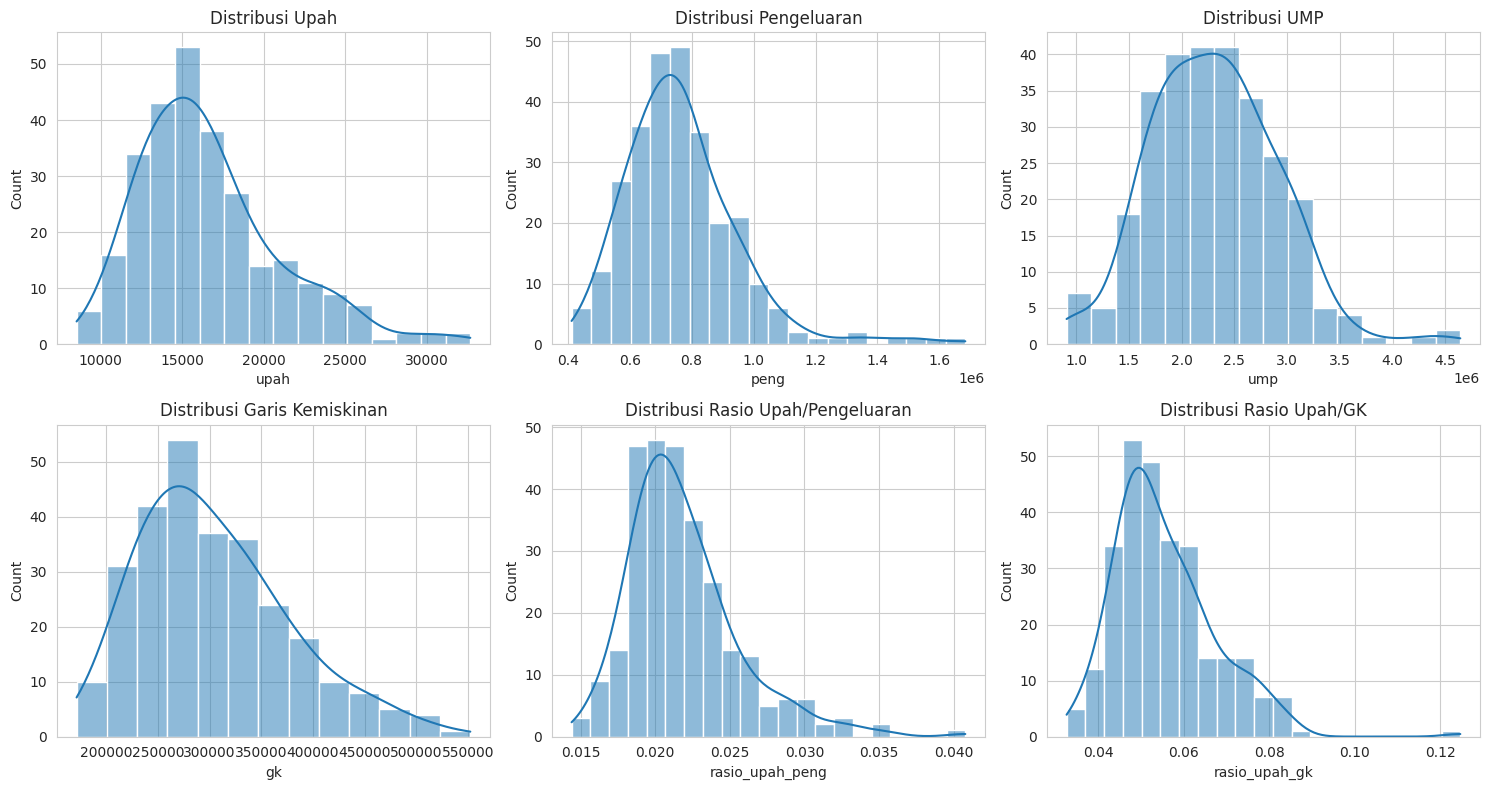

In [199]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# plt.subplots(2, 3): buat kanvas dengan 2 baris dan 3 kolom subplot (total 6 plot)
# figsize=(15, 8): ukuran keseluruhan kanvas 15x8 inci
# fig = objek figure utama, axes = array 2D berisi objek subplot [baris][kolom]

sns.histplot(df['upah'], kde=True, ax=axes[0,0])
# sns.histplot(): plot histogram distribusi frekuensi data
# kde=True: tambahkan kurva KDE (Kernel Density Estimation) untuk estimasi distribusi kontinu
# ax=axes[0,0]: tempatkan plot di baris 0, kolom 0 (pojok kiri atas)
axes[0,0].set_title('Distribusi Upah')       # set judul subplot ini

sns.histplot(df['peng'], kde=True, ax=axes[0,1])  # histogram pengeluaran di posisi [0,1]
axes[0,1].set_title('Distribusi Pengeluaran')

sns.histplot(df['ump'], kde=True, ax=axes[0,2])   # histogram UMP di posisi [0,2]
axes[0,2].set_title('Distribusi UMP')

sns.histplot(df['gk'], kde=True, ax=axes[1,0])    # histogram garis kemiskinan di posisi [1,0]
axes[1,0].set_title('Distribusi Garis Kemiskinan')

sns.histplot(df['rasio_upah_peng'], kde=True, ax=axes[1,1])  # histogram rasio di posisi [1,1]
axes[1,1].set_title('Distribusi Rasio Upah/Pengeluaran')

sns.histplot(df['rasio_upah_gk'], kde=True, ax=axes[1,2])   # histogram rasio GK di posisi [1,2]
axes[1,2].set_title('Distribusi Rasio Upah/GK')

plt.tight_layout()  # otomatis atur jarak antar subplot agar tidak saling tumpang tindih
plt.show()          # render dan tampilkan semua plot ke layar

### 7.2 Distribusi Kelas Target

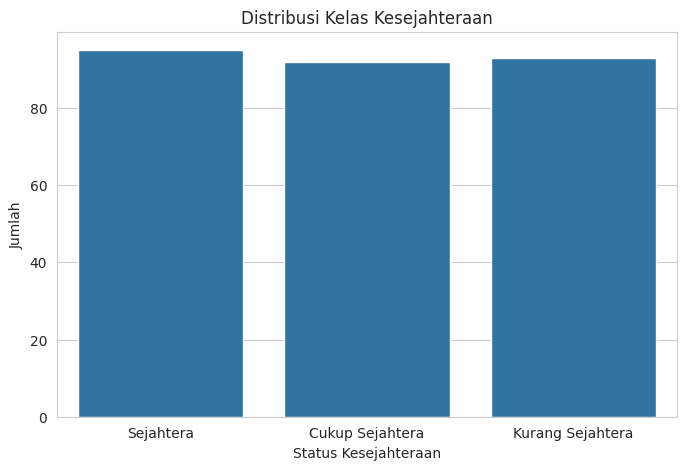

welfare_status
Sejahtera           95
Kurang Sejahtera    93
Cukup Sejahtera     92
Name: count, dtype: int64


In [200]:
sns.countplot(x='welfare_status', data=df,
              order=['Sejahtera','Cukup Sejahtera','Kurang Sejahtera'])
# sns.countplot(): buat bar chart yang menghitung frekuensi tiap kategori
# x='welfare_status': kolom yang ingin dihitung frekuensinya (sumbu x)
# data=df: DataFrame sumber data
# order=[...]: tentukan urutan tampilan bar dari kiri ke kanan

plt.title('Distribusi Kelas Kesejahteraan')  # judul grafik
plt.xlabel('Status Kesejahteraan')           # label sumbu x
plt.ylabel('Jumlah')                         # label sumbu y
plt.show()                                   # tampilkan grafik
print(df['welfare_status'].value_counts())   # tampilkan juga angka pastinya di output teks

### 7.3 Boxplot Cek Outlier

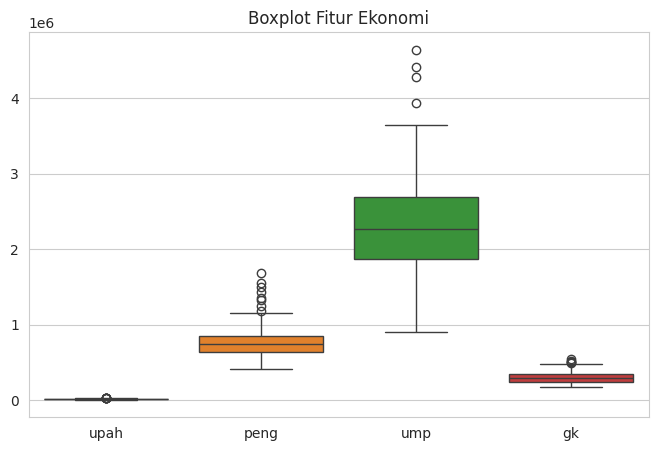

In [201]:
sns.boxplot(data=df[['upah','peng','ump','gk']])
# sns.boxplot(): plot box-and-whisker untuk melihat sebaran dan outlier
# df[['upah','peng','ump','gk']]: pilih 4 kolom numerik untuk divisualisasikan sekaligus
# box menunjukkan: Q1 (25%), median (50%), Q3 (75%)
# whisker menunjukkan: rentang data normal (1.5x IQR dari box)
# titik di luar whisker = outlier

plt.title('Boxplot Fitur Ekonomi')  # judul grafik
plt.show()

### 7.4 Heatmap Korelasi

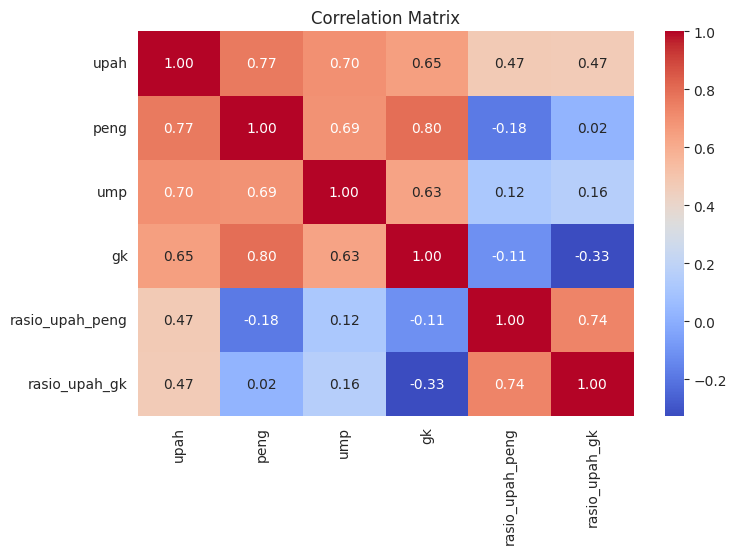

In [203]:
corr = df[['upah','peng','ump','gk','rasio_upah_peng','rasio_upah_gk']].corr()
# .corr(): hitung matriks korelasi Pearson antar semua pasangan kolom numerik
# nilai korelasi: +1 (sangat positif), 0 (tidak ada korelasi), -1 (sangat negatif)
# hanya ambil 6 kolom numerik yang relevan untuk analisis

sns.heatmap(corr,
            annot=True,         # tampilkan nilai korelasi di dalam setiap sel
            cmap='coolwarm',    # palet warna: biru (negatif) → putih (nol) → merah (positif)
            fmt='.2f')          # format angka: 2 desimal
plt.title('Correlation Matrix')
plt.show()

### 7.5 Scatter Plot

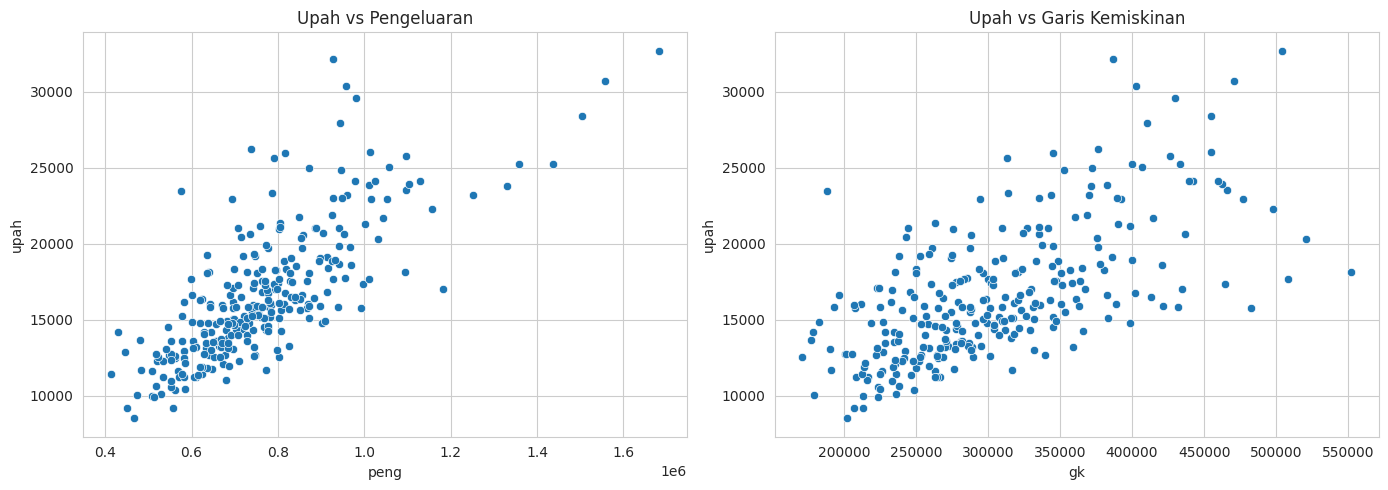

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# buat 2 subplot berdampingan (1 baris, 2 kolom) berukuran 14x5 inci

sns.scatterplot(x='peng', y='upah', data=df, ax=axes[0])
# sns.scatterplot(): plot titik-titik data untuk melihat hubungan dua variabel
# x='peng': sumbu horizontal = nilai pengeluaran
# y='upah': sumbu vertikal = nilai upah
# jika titik membentuk pola diagonal = ada korelasi antara kedua variabel
axes[0].set_title('Upah vs Pengeluaran')   # judul subplot kiri

sns.scatterplot(x='gk', y='upah', data=df, ax=axes[1])
# scatter plot hubungan antara garis kemiskinan (sumbu x) dengan upah (sumbu y)
axes[1].set_title('Upah vs Garis Kemiskinan')  # judul subplot kanan

plt.tight_layout()  # atur jarak antar subplot
plt.show()

### 7.6 Fitur vs Target

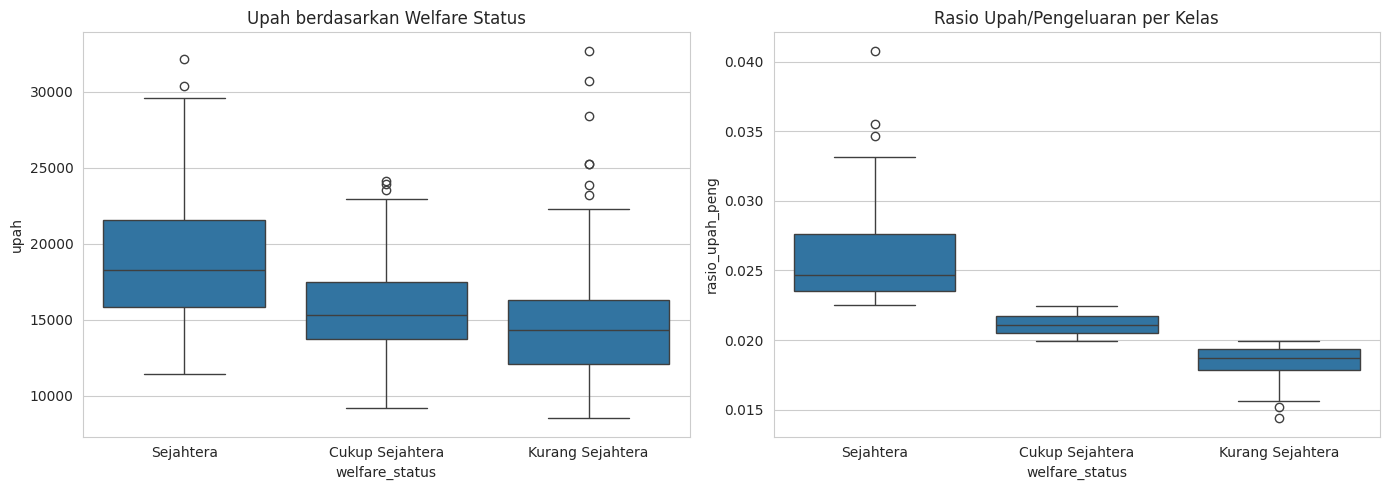

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 2 subplot berdampingan

order = ['Sejahtera','Cukup Sejahtera','Kurang Sejahtera']
# list order: tentukan urutan kategori dari kiri ke kanan pada sumbu x

sns.boxplot(x='welfare_status', y='upah', data=df, order=order, ax=axes[0])
# boxplot untuk melihat distribusi upah PADA SETIAP kelas kesejahteraan
# x='welfare_status': sumbu x = kategori kelas
# y='upah': sumbu y = nilai upah yang dibandingkan
# berguna untuk melihat apakah kelas berbeda memiliki distribusi upah yang berbeda
axes[0].set_title('Upah berdasarkan Welfare Status')

sns.boxplot(x='welfare_status', y='rasio_upah_peng', data=df, order=order, ax=axes[1])
# boxplot untuk melihat distribusi rasio_upah_peng pada setiap kelas
# ini memverifikasi bahwa label yang dibuat sudah memisahkan kelas dengan baik
axes[1].set_title('Rasio Upah/Pengeluaran per Kelas')

plt.tight_layout()
plt.show()

### 7.7 Tren Upah per Tahun

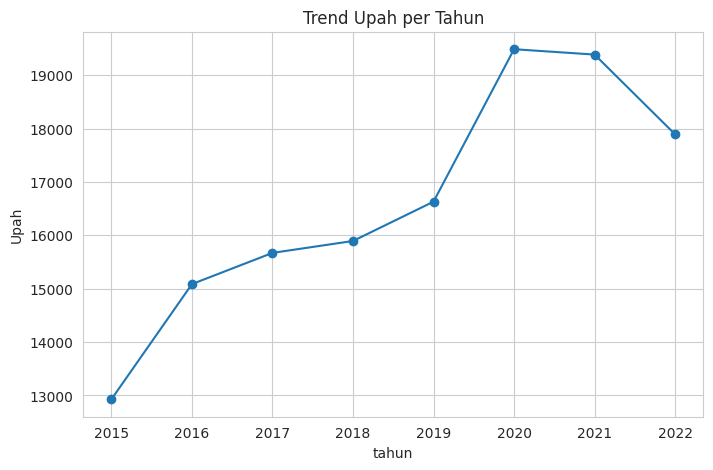

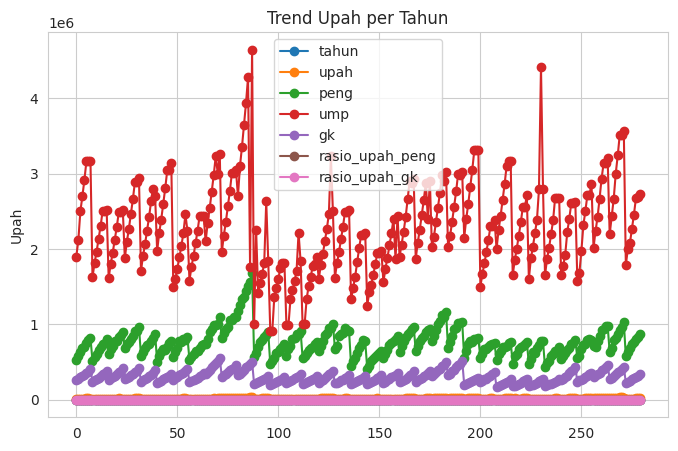

In [209]:
df.groupby('tahun')['upah'].mean().plot(marker='o')
plt.title('Trend Upah per Tahun')
plt.ylabel('Upah')
plt.show()

### 7.8 Top 10 Provinsi Berdasarkan Upah

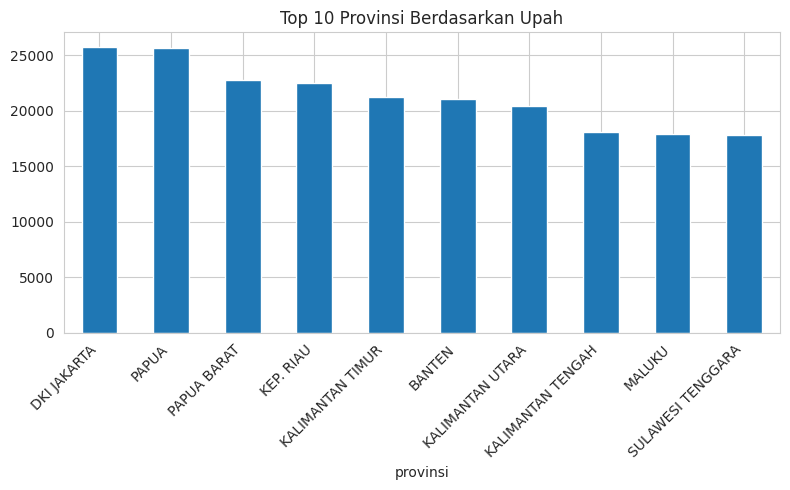

In [210]:
top = df.groupby('provinsi')['upah'].mean().sort_values(ascending=False).head(10)
# df.groupby('provinsi'): kelompokkan data berdasarkan nama provinsi
# ['upah'].mean(): hitung rata-rata upah per provinsi (rata-rata semua tahun)
# .sort_values(ascending=False): urutkan dari nilai tertinggi ke terendah
# .head(10): ambil hanya 10 provinsi teratas

top.plot(kind='bar')                      # buat bar chart vertikal dari Series 'top'
plt.title('Top 10 Provinsi Berdasarkan Upah')  # judul grafik
plt.xticks(rotation=45, ha='right')       # putar label sumbu x 45 derajat, rata kanan
plt.tight_layout()                        # atur layout agar label tidak terpotong
plt.show()

## 8. Persiapan Model MLP

### 8.1 Simpan Dataset Final

In [184]:
df.to_csv('final_dataset.csv', index=False)
# df.to_csv(): ekspor DataFrame ke file CSV
# 'final_dataset.csv': nama file output yang akan dibuat
# index=False: jangan sertakan kolom index angka (0,1,2,...) dalam file CSV

print('Dataset disimpan ke final_dataset.csv')  # konfirmasi penyimpanan berhasil
print('Shape:', df.shape)                        # tampilkan dimensi akhir dataset (baris x kolom)

Dataset disimpan ke final_dataset.csv
Shape: (280, 9)


### 8.2 Fitur dan Target

In [211]:
# ── DEFINISI FITUR (X) ────────────────────────────────────────────────────────
X = df[['upah', 'peng', 'ump', 'gk', 'rasio_upah_peng', 'rasio_upah_gk']]
# X: matriks fitur (input model) berisi 6 kolom numerik
# upah: nilai upah pekerja
# peng: rata-rata pengeluaran per kapita
# ump: upah minimum provinsi
# gk: garis kemiskinan
# rasio_upah_peng: fitur turunan — perbandingan upah vs pengeluaran
# rasio_upah_gk: fitur turunan — perbandingan upah vs garis kemiskinan

# ── DEFINISI TARGET (y) ───────────────────────────────────────────────────────
y = df['welfare_status']
# y: vektor target (output yang ingin diprediksi)
# berisi label kategori: 'Sejahtera', 'Cukup Sejahtera', 'Kurang Sejahtera'

print('Fitur:', X.columns.tolist())  # tampilkan nama semua kolom fitur
print('Target:', y.name)             # tampilkan nama kolom target
print('Shape X:', X.shape)           # tampilkan dimensi X: (280, 6)

Fitur: ['upah', 'peng', 'ump', 'gk', 'rasio_upah_peng', 'rasio_upah_gk']
Target: welfare_status
Shape X: (280, 6)


### 8.3 Encode Label

```
Cukup Sejahtera  → 0
Kurang Sejahtera → 1
Sejahtera        → 2
```

In [212]:
le = LabelEncoder()
# LabelEncoder(): inisialisasi objek encoder
# encoder ini akan memetakan setiap kategori unik ke angka integer

y_enc = le.fit_transform(y)
# .fit_transform(y): dua langkah sekaligus:
#   1. fit: pelajari semua kategori unik dalam y dan tentukan urutan alfabetisnya
#   2. transform: ubah setiap label string menjadi angka integer
#      'Cukup Sejahtera' → 0 (huruf C paling awal secara alfabet)
#      'Kurang Sejahtera' → 1 (huruf K kedua)
#      'Sejahtera' → 2 (huruf S terakhir)

print('Kelas:', le.classes_)
# le.classes_: array berisi nama kelas yang dipelajari, berurutan sesuai encoding

print('Contoh encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
# zip(le.classes_, le.transform(...)): pasangkan nama kelas dengan angka encoding-nya
# dict(): ubah menjadi dictionary untuk tampilan yang mudah dibaca

Kelas: ['Cukup Sejahtera' 'Kurang Sejahtera' 'Sejahtera']
Contoh encoding: {'Cukup Sejahtera': np.int64(0), 'Kurang Sejahtera': np.int64(1), 'Sejahtera': np.int64(2)}


### 8.4 Split Data (Train/Test)

In [213]:
X_train, X_test, y_train, y_test = train_test_split(
    X,              # matriks fitur yang akan dibagi
    y_enc,          # vektor target (dalam bentuk angka)
    test_size=0.2,  # 20% data dialokasikan untuk testing, 80% untuk training
    random_state=42, # seed angka acak untuk reproducibility (hasil split selalu sama)
    stratify=y_enc  # stratified split: jaga proporsi tiap kelas sama di train & test
                    # tanpa stratify, split bisa tidak seimbang secara kebetulan
)
# hasil: 224 baris untuk training (80%), 56 baris untuk testing (20%)

print(f'Data train : {X_train.shape[0]} baris')  # tampilkan jumlah baris data training
print(f'Data test  : {X_test.shape[0]} baris')   # tampilkan jumlah baris data testing

Data train : 224 baris
Data test  : 56 baris


### 8.5 Scaling Fitur

In [214]:
scaler = StandardScaler()
# StandardScaler(): inisialisasi objek scaler
# akan mengubah setiap fitur sehingga mean = 0 dan standard deviation = 1
# scaling penting untuk MLP karena jaringan saraf sensitif terhadap skala fitur

X_train = scaler.fit_transform(X_train)
# .fit_transform(X_train): dua langkah sekaligus HANYA pada data train:
#   1. fit: hitung mean dan std setiap fitur DARI DATA TRAIN
#   2. transform: terapkan rumus: (x - mean) / std pada setiap nilai
# PENTING: fit hanya dari data train, bukan test, untuk mencegah data leakage

X_test = scaler.transform(X_test)
# .transform(X_test): terapkan scaling ke data test menggunakan mean & std dari train
# JANGAN gunakan fit_transform di sini — scaler sudah di-fit dari data train
# ini memastikan data test "tidak terlihat" saat training

print('Scaling selesai!')
print('Mean train (seharusnya ~0):', X_train.mean(axis=0).round(2))
# verifikasi: rata-rata setiap fitur setelah scaling seharusnya mendekati 0

Scaling selesai!
Mean train (seharusnya ~0): [-0.  0.  0. -0. -0. -0.]


## 9. Model Multi-Layer Perceptron (MLP)

Arsitektur model:
- Input layer: 6 fitur
- Hidden layer 1: 64 neuron
- Hidden layer 2: 32 neuron
- Output layer: 3 kelas
- Fungsi aktivasi: ReLU
- Optimizer: Adam

In [215]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    # tuple yang mendefinisikan arsitektur hidden layer:
    # (64, 32) = 2 hidden layer: layer pertama 64 neuron, layer kedua 32 neuron
    # neuron lebih banyak di layer awal, mengecil di layer berikutnya (funnel shape)

    activation='relu',
    # fungsi aktivasi setiap neuron di hidden layer
    # ReLU (Rectified Linear Unit): f(x) = max(0, x)
    # mengatasi vanishing gradient, komputasi cepat, cocok untuk kebanyakan kasus

    solver='adam',
    # algoritma optimasi untuk memperbarui bobot (weights) jaringan
    # Adam (Adaptive Moment Estimation): adaptif, efisien, konvergen lebih cepat
    # alternatif: 'sgd' (Stochastic Gradient Descent)

    max_iter=500,
    # jumlah maksimum epoch (iterasi penuh melewati seluruh data training)
    # training akan berhenti jika mencapai 500 iterasi atau early stopping terpicu

    early_stopping=True,
    # aktifkan early stopping: training otomatis berhenti jika
    # performa validasi tidak meningkat selama n_iter_no_change iterasi berturut-turut
    # mencegah overfitting dan menghemat waktu komputasi

    random_state=42
    # seed angka acak untuk inisialisasi bobot jaringan
    # memastikan hasil training bisa direproduksi (selalu sama setiap dijalankan)
)
print('Model MLP berhasil didefinisikan!')
print(model)  # tampilkan ringkasan konfigurasi model

Model MLP berhasil didefinisikan!
MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=500,
              random_state=42)


### 9.1 Training Model

In [216]:
model.fit(X_train, y_train)
# .fit(): latih model dengan data training
# X_train: matriks fitur training (sudah di-scale)
# y_train: vektor target training (dalam bentuk angka 0,1,2)
# proses: forward pass → hitung loss → backpropagation → update bobot → ulangi
# model belajar pola dari data untuk meminimalkan fungsi loss (cross-entropy)

print('Training selesai!')
print(f'Jumlah iterasi: {model.n_iter_}')
# model.n_iter_: jumlah iterasi aktual yang dijalankan
# jika < max_iter (500), berarti early stopping menghentikan training lebih awal

Training selesai!
Jumlah iterasi: 40


### 9.2 Prediksi

In [217]:
y_pred = model.predict(X_test)
# .predict(): gunakan model yang sudah terlatih untuk memprediksi kelas data test
# X_test: matriks fitur testing (sudah di-scale dengan scaler yang sama)
# hasil: array angka (0, 1, atau 2) yang merepresentasikan kelas prediksi
# model memilih kelas dengan probabilitas tertinggi dari output layer (softmax)

print('Prediksi selesai!')

Prediksi selesai!


## 10. Evaluasi Model

In [218]:
print('Accuracy:', accuracy_score(y_test, y_pred))
# accuracy_score(): hitung akurasi keseluruhan model
# rumus: jumlah prediksi benar / total prediksi
# y_test: label aktual data test
# y_pred: label hasil prediksi model
# nilai 0.82 berarti 82% data test diprediksi dengan benar

Accuracy: 0.8214285714285714


In [219]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))
# classification_report(): laporan evaluasi detail per kelas
# target_names=le.classes_: gunakan nama kelas asli (bukan angka 0,1,2)
# Kolom yang ditampilkan:
#   precision: dari semua yang diprediksi kelas X, berapa % yang benar-benar kelas X?
#              rumus: TP / (TP + FP)
#   recall: dari semua data yang sebenarnya kelas X, berapa % yang terdeteksi?
#           rumus: TP / (TP + FN)
#   f1-score: rata-rata harmonik precision dan recall (keseimbangan keduanya)
#             rumus: 2 * (precision * recall) / (precision + recall)
#   support: jumlah data aktual per kelas di test set

Classification Report:
                  precision    recall  f1-score   support

 Cukup Sejahtera       0.75      0.67      0.71        18
Kurang Sejahtera       0.82      0.95      0.88        19
       Sejahtera       0.89      0.84      0.86        19

        accuracy                           0.82        56
       macro avg       0.82      0.82      0.82        56
    weighted avg       0.82      0.82      0.82        56



Confusion Matrix:
[[12  4  2]
 [ 1 18  0]
 [ 3  0 16]]


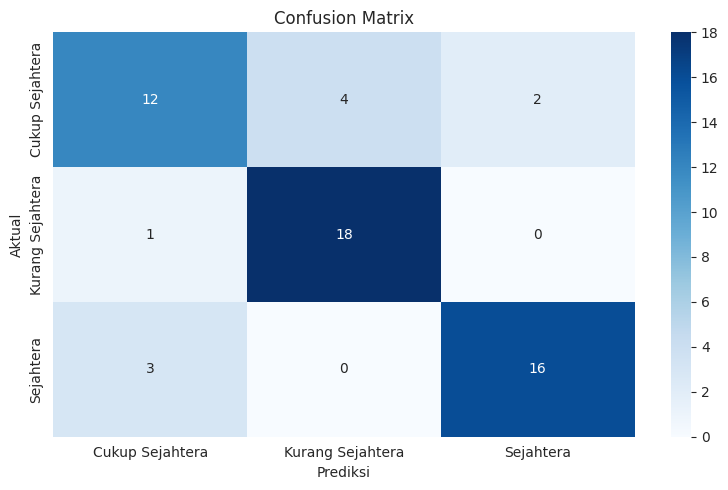

In [220]:
print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
# confusion_matrix(): buat matriks NxN (N = jumlah kelas)
# baris = kelas aktual, kolom = kelas prediksi
# diagonal utama (kiri atas ke kanan bawah) = prediksi benar
# di luar diagonal = prediksi salah (misklasifikasi)
print(cm)

# ── VISUALISASI CONFUSION MATRIX ─────────────────────────────────────────────
sns.heatmap(cm,
            annot=True,             # tampilkan angka di dalam setiap sel matriks
            fmt='d',                # format angka sebagai integer (bukan desimal)
            cmap='Blues',           # palet warna: putih (0) → biru tua (nilai tinggi)
            xticklabels=le.classes_, # label kolom = nama kelas prediksi
            yticklabels=le.classes_) # label baris = nama kelas aktual
plt.title('Confusion Matrix')    # judul grafik
plt.ylabel('Aktual')             # label sumbu y = kelas yang sebenarnya
plt.xlabel('Prediksi')           # label sumbu x = kelas yang diprediksi model
plt.tight_layout()               # atur layout agar label tidak terpotong
plt.show()

### Interpretasi Hasil

Model MLP berhasil mengklasifikasikan kesejahteraan pekerja dengan **akurasi ~82%**.

**Insight utama:**
- Label dibuat berbasis persentil `rasio_upah_peng`, menghasilkan distribusi kelas yang seimbang (~93 data per kelas)
- Kelas **Sejahtera** dan **Kurang Sejahtera** diprediksi dengan precision dan recall yang baik
- Kelas **Cukup Sejahtera** (kelas tengah) lebih sulit diprediksi karena batas antar kelas lebih tipis
- Korelasi antara `rasio_upah_peng` dengan label yang jelas membuat model bisa belajar dengan baik

## 11. Simpan Model

In [221]:
joblib.dump(model,  'mlp_model.pkl')
# joblib.dump(): serialisasi objek Python ke file binary (.pkl)
# model: objek MLPClassifier yang sudah terlatih beserta semua bobotnya
# 'mlp_model.pkl': nama file output (pkl = pickle format)
# tujuan: agar model bisa digunakan kembali tanpa harus training ulang

joblib.dump(scaler, 'scaler.pkl')
# simpan objek StandardScaler yang sudah di-fit
# PENTING: scaler harus disimpan bersama model karena data baru
# perlu di-transform dengan scaler yang SAMA saat inference (prediksi baru)

joblib.dump(le,     'label_encoder.pkl')
# simpan objek LabelEncoder yang sudah di-fit
# diperlukan untuk mengubah kembali angka prediksi (0,1,2)
# menjadi nama kelas asli ('Sejahtera', dll) saat inference

print('Model berhasil disimpan!')
print('Files: mlp_model.pkl, scaler.pkl, label_encoder.pkl')
# untuk memuat kembali: loaded_model = joblib.load('mlp_model.pkl')

Model berhasil disimpan!
Files: mlp_model.pkl, scaler.pkl, label_encoder.pkl
